In [20]:
import sys 
import os

current_dir = os.path.dirname(os.path.abspath('.'))
project_root = os.path.abspath(os.path.join(current_dir, ".."))
sys.path.insert(0, project_root)

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
plt.style.use('ggplot')

In [3]:
from Titanic.src.utils.plots import plot_numerical_data

# Read Dataset

In [4]:
pipeline_name = "Pipeline1"

In [5]:
X_train = pd.read_parquet(fr'..\data\feature_eng\X_train_feat_eng_{pipeline_name}.parquet')
y_train = pd.read_parquet(fr'..\data\feature_eng\y_train_feat_eng_{pipeline_name}.parquet')

In [6]:
df = pd.concat([X_train, y_train], axis=1)

In [7]:
print(f'Dataset rows and columns: {df.shape}')

Dataset rows and columns: (712, 15)


In [8]:
df.head()

,numerical_pipe_con__Age,numerical_pipe_dis__SibSp,numerical_pipe_dis__Parch,numerical_pipe_dis__IsAlone,categorical_pipe__Pclass_1,categorical_pipe__Pclass_2,categorical_pipe__Sex_male,categorical_pipe__Embarked_S,categorical_pipe__Embarked_C,categorical_pipe__Embarked_Q,categorical_pipe__Title_Mr,categorical_pipe__Title_Miss,categorical_pipe__Title_Rare,categorical_pipe__Title_Mrs,Survived
331,1.253641,0.000,0.000000,1.0,1,0,1,1,0,0,1,0,0,0,0
733,-0.477284,0.000,0.000000,1.0,0,1,1,1,0,0,1,0,0,0,0
382,0.215086,0.000,0.000000,1.0,0,0,1,1,0,0,1,0,0,0,0
704,-0.246494,0.125,0.000000,0.0,0,0,1,1,0,0,1,0,0,0,0
813,-1.785093,0.500,0.333333,0.0,0,0,0,1,0,0,0,1,0,0,0


In [9]:
num_var = df.select_dtypes(include=['number']).columns
num_var

Index(['numerical_pipe_con__Age', 'numerical_pipe_dis__SibSp',
       'numerical_pipe_dis__Parch', 'numerical_pipe_dis__IsAlone',
       'categorical_pipe__Pclass_1', 'categorical_pipe__Pclass_2',
       'categorical_pipe__Sex_male', 'categorical_pipe__Embarked_S',
       'categorical_pipe__Embarked_C', 'categorical_pipe__Embarked_Q',
       'categorical_pipe__Title_Mr', 'categorical_pipe__Title_Miss',
       'categorical_pipe__Title_Rare', 'categorical_pipe__Title_Mrs',
       'Survived'],
      dtype='object')

# Exploratory Analisys

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 331 to 102
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   numerical_pipe_con__Age       712 non-null    float64
 1   numerical_pipe_dis__SibSp     712 non-null    float64
 2   numerical_pipe_dis__Parch     712 non-null    float64
 3   numerical_pipe_dis__IsAlone   712 non-null    float64
 4   categorical_pipe__Pclass_1    712 non-null    int32  
 5   categorical_pipe__Pclass_2    712 non-null    int32  
 6   categorical_pipe__Sex_male    712 non-null    int32  
 7   categorical_pipe__Embarked_S  712 non-null    int32  
 8   categorical_pipe__Embarked_C  712 non-null    int32  
 9   categorical_pipe__Embarked_Q  712 non-null    int32  
 10  categorical_pipe__Title_Mr    712 non-null    int32  
 11  categorical_pipe__Title_Miss  712 non-null    int32  
 12  categorical_pipe__Title_Rare  712 non-null    int32  
 13  categori

# Check NA values

<Axes: >

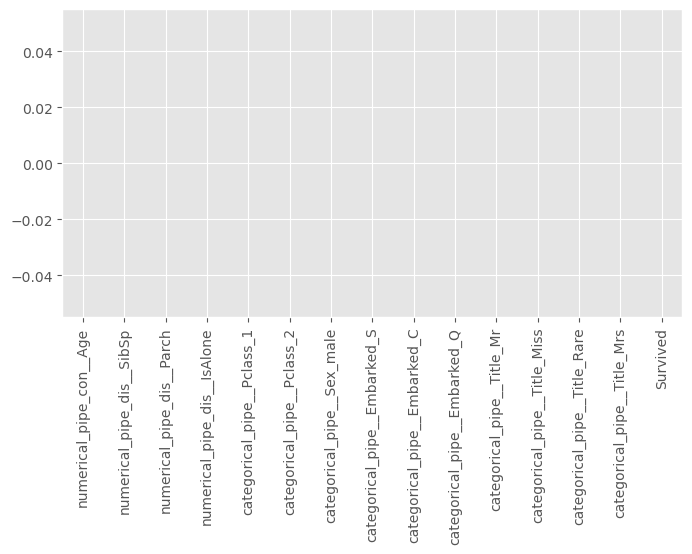

In [11]:
df.isna().mean().plot.bar(figsize=(8,4))

# Check Cardinality

In [12]:
for col in num_var:
    print('Numero de labels por variável na coluna: ' + col + ' ' + str(df[col].nunique()))

Numero de labels por variável na coluna: numerical_pipe_con__Age 83
Numero de labels por variável na coluna: numerical_pipe_dis__SibSp 7
Numero de labels por variável na coluna: numerical_pipe_dis__Parch 7
Numero de labels por variável na coluna: numerical_pipe_dis__IsAlone 2
Numero de labels por variável na coluna: categorical_pipe__Pclass_1 2
Numero de labels por variável na coluna: categorical_pipe__Pclass_2 2
Numero de labels por variável na coluna: categorical_pipe__Sex_male 2
Numero de labels por variável na coluna: categorical_pipe__Embarked_S 2
Numero de labels por variável na coluna: categorical_pipe__Embarked_C 2
Numero de labels por variável na coluna: categorical_pipe__Embarked_Q 2
Numero de labels por variável na coluna: categorical_pipe__Title_Mr 2
Numero de labels por variável na coluna: categorical_pipe__Title_Miss 2
Numero de labels por variável na coluna: categorical_pipe__Title_Rare 2
Numero de labels por variável na coluna: categorical_pipe__Title_Mrs 2
Numero de la

# Plots

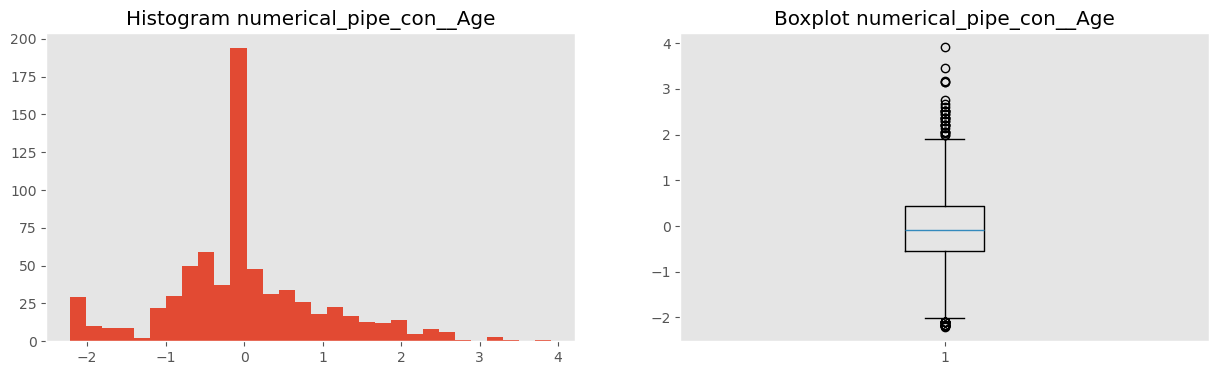

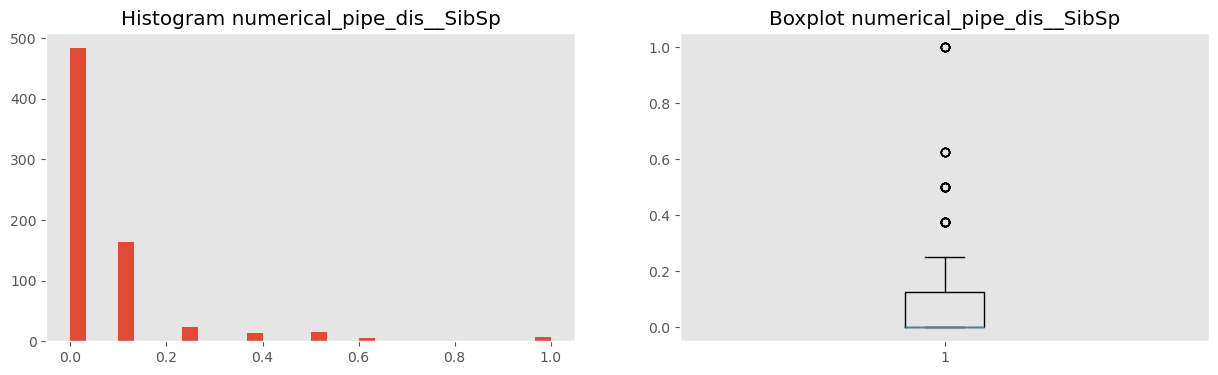

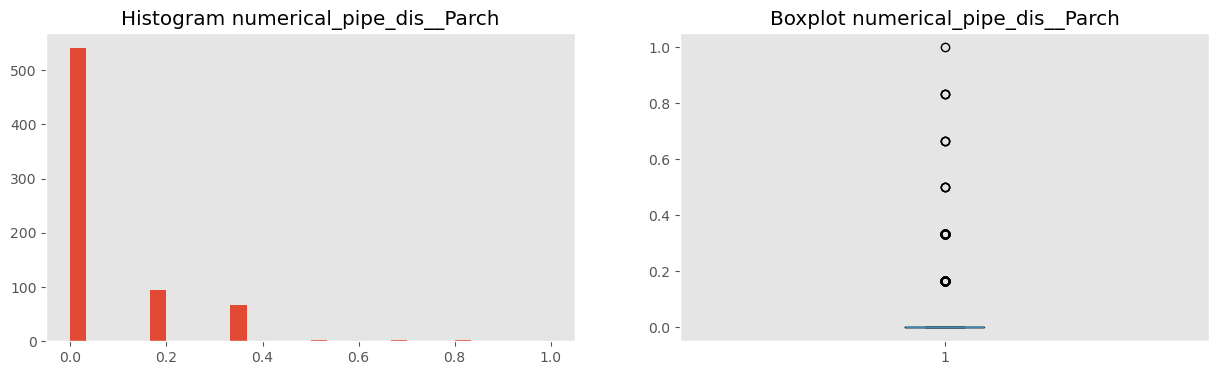

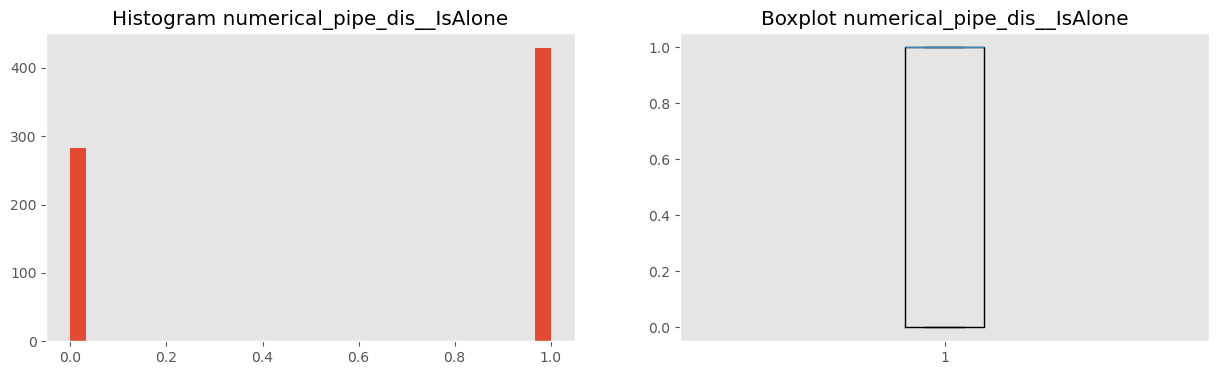

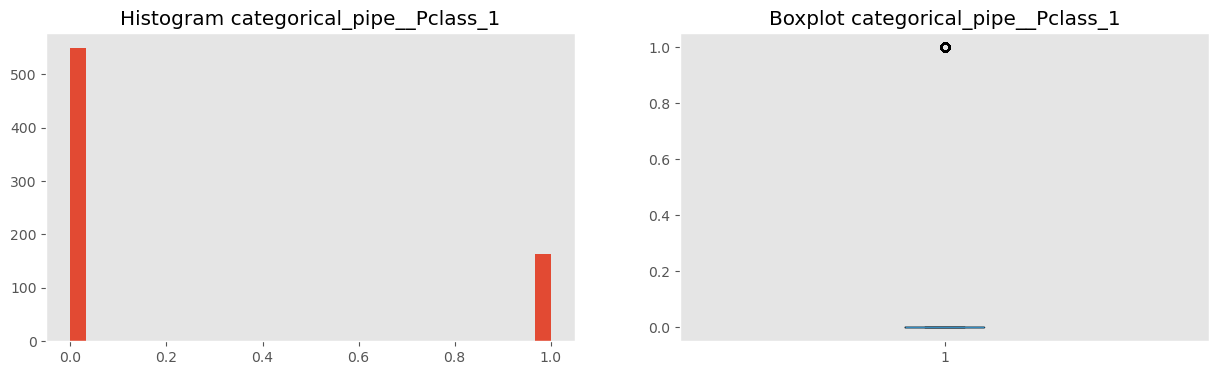

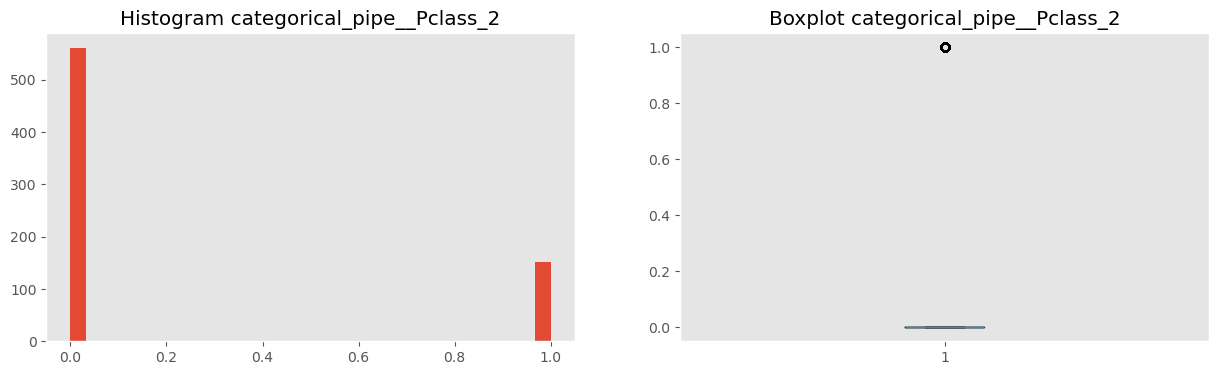

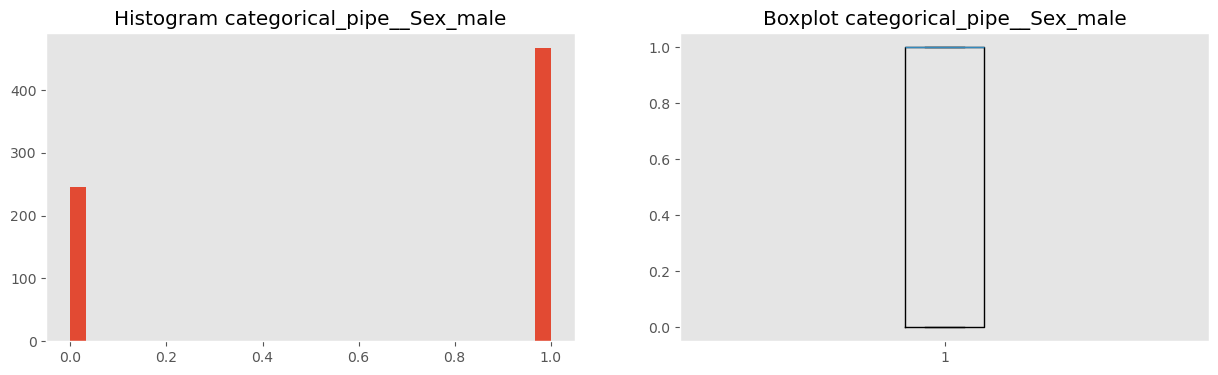

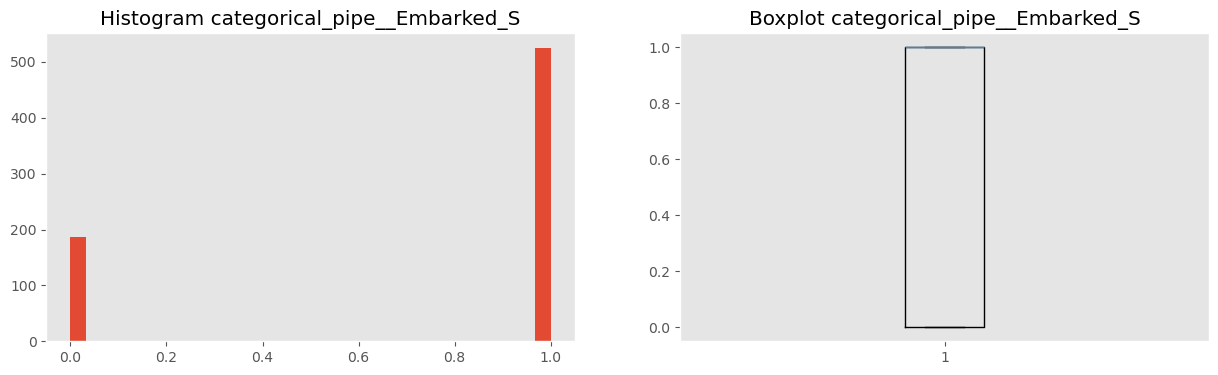

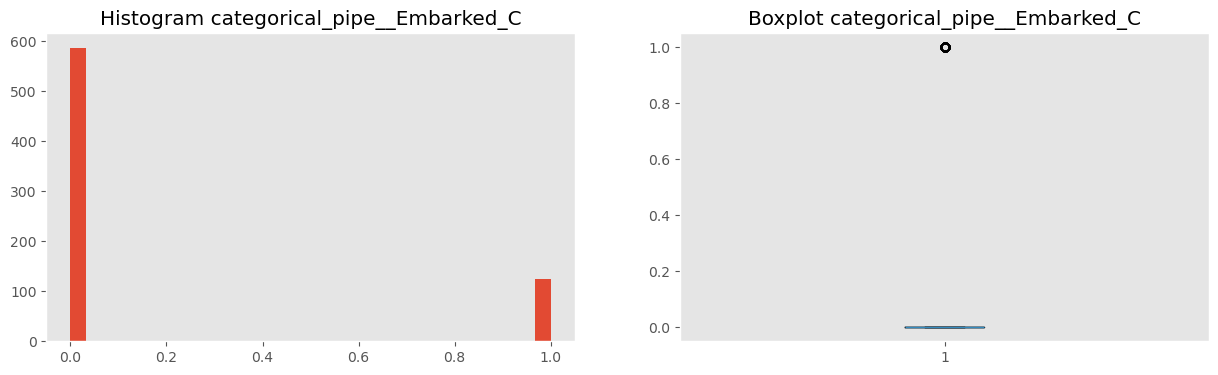

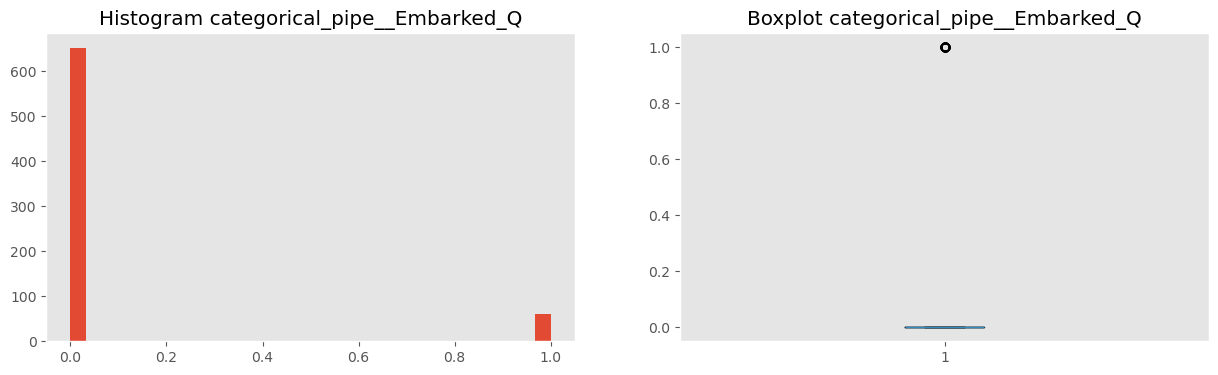

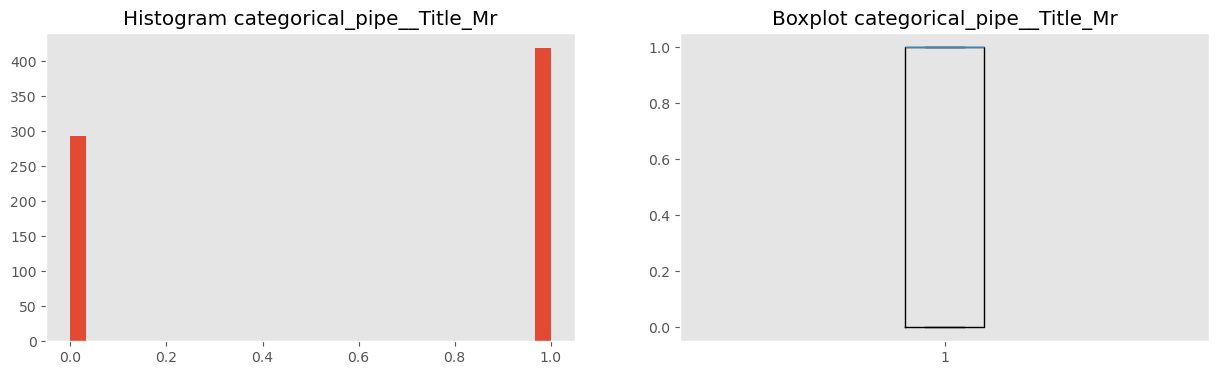

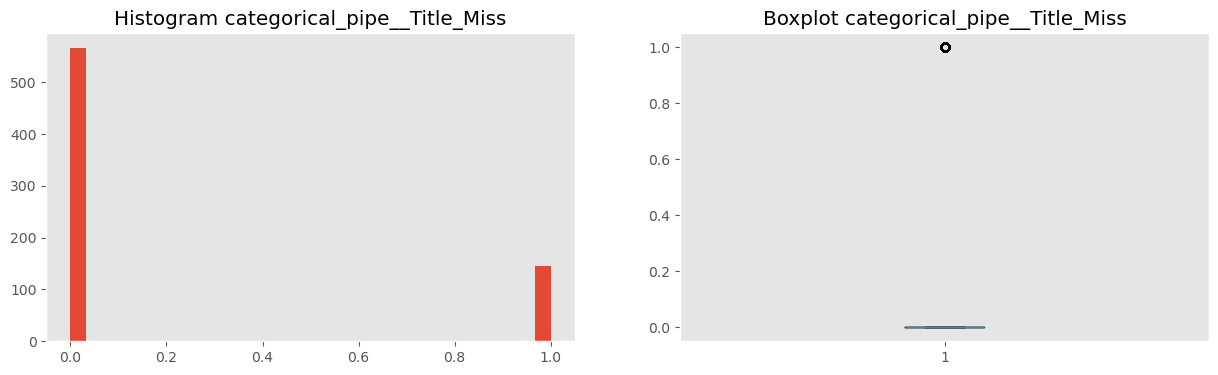

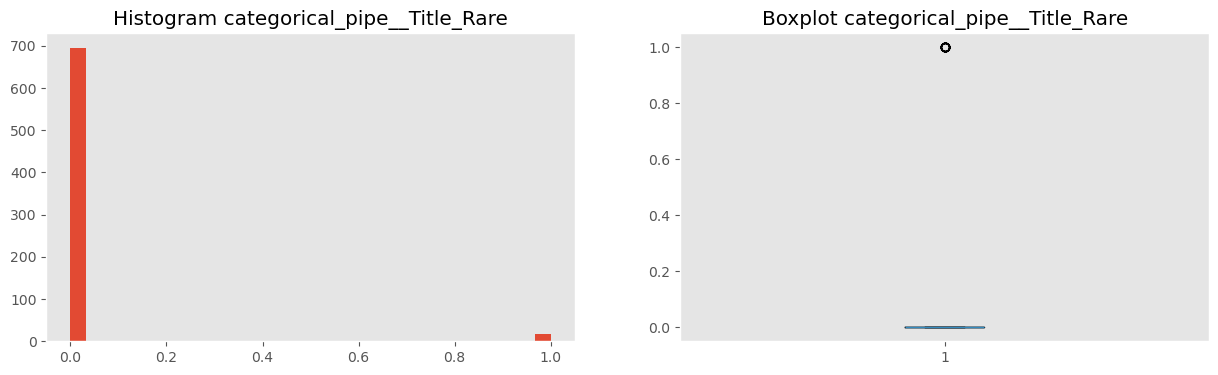

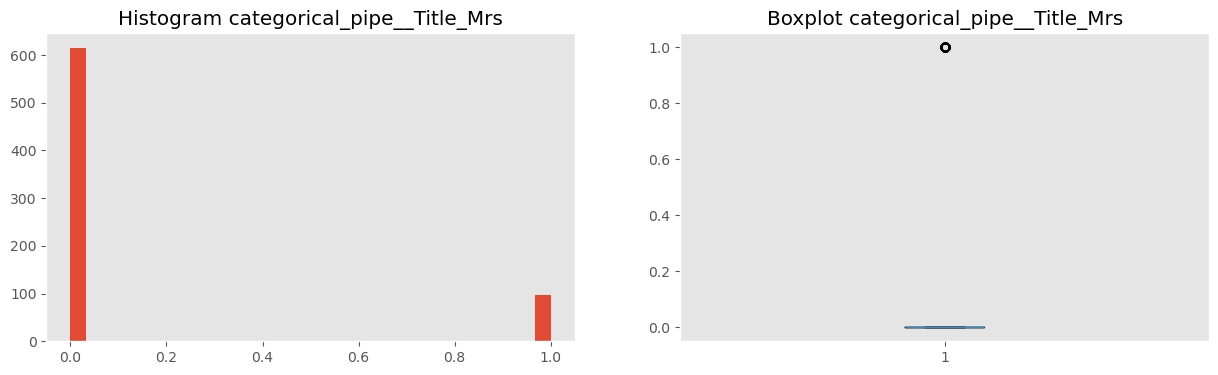

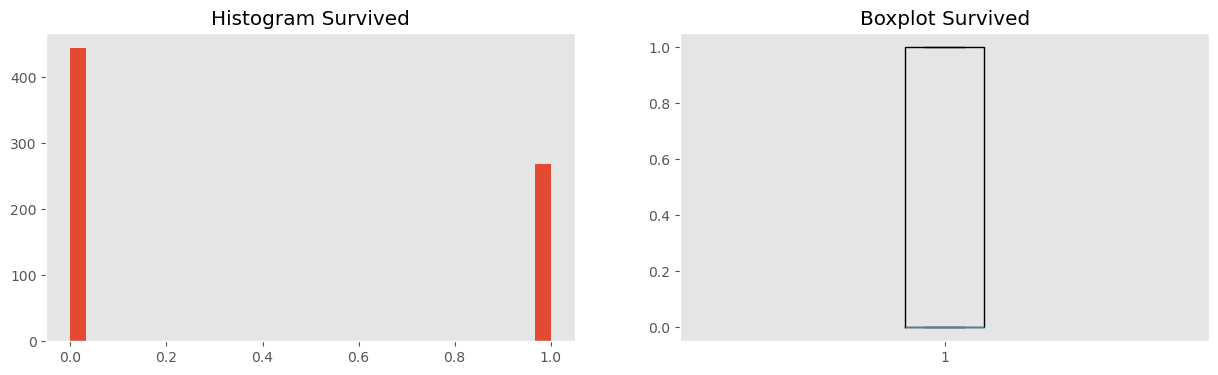

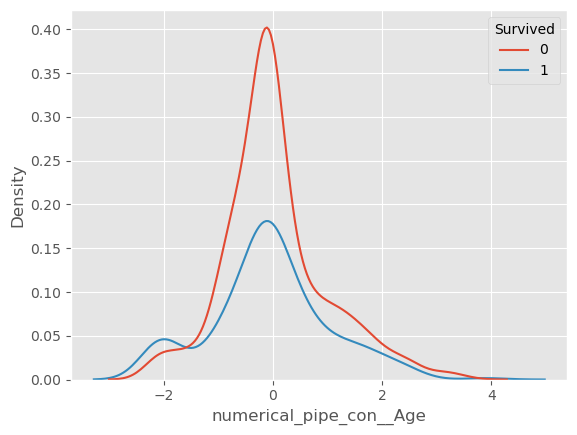

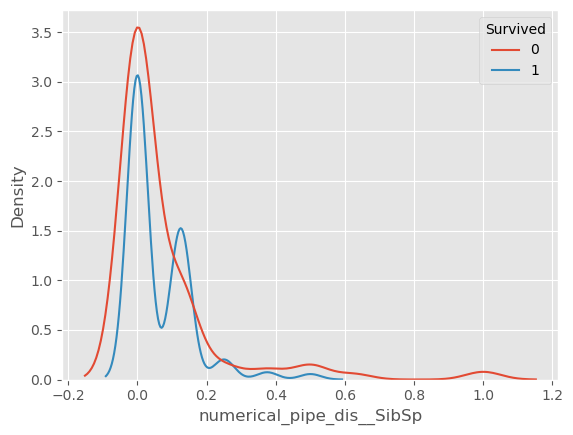

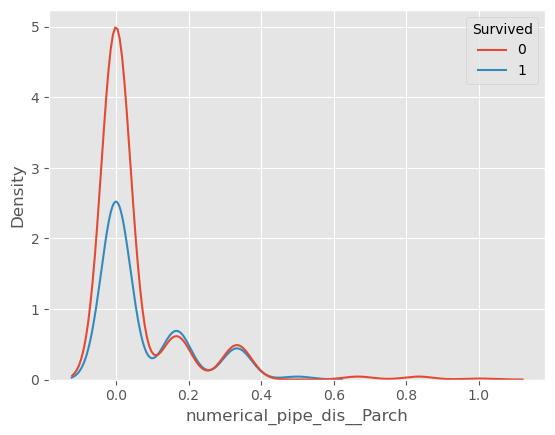

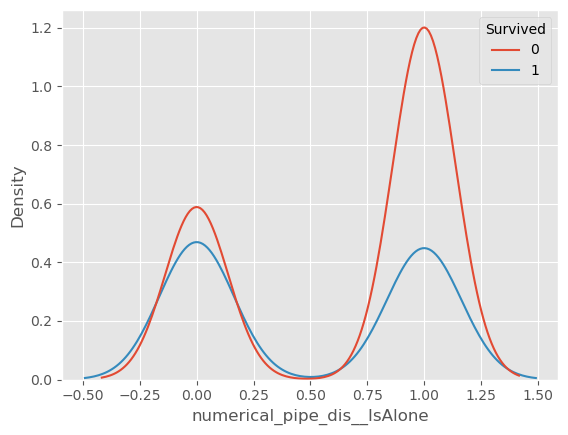

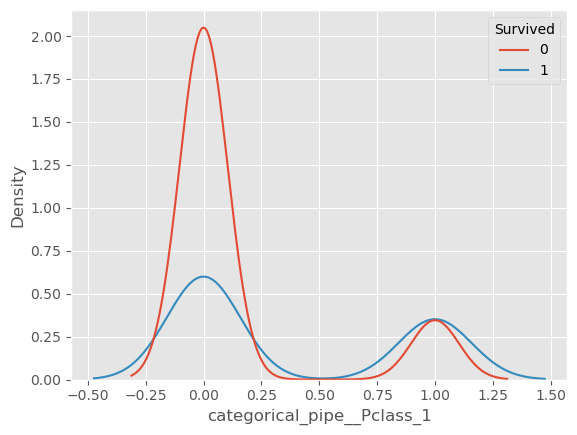

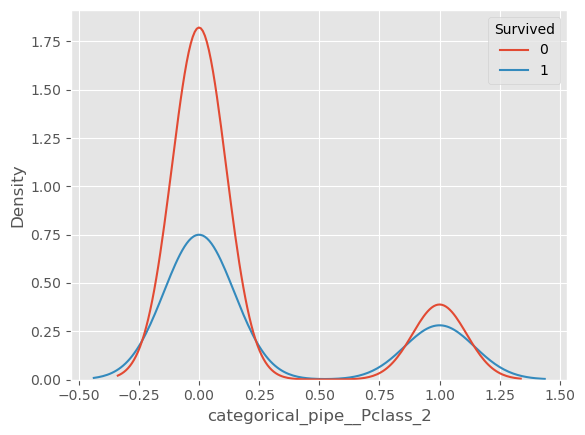

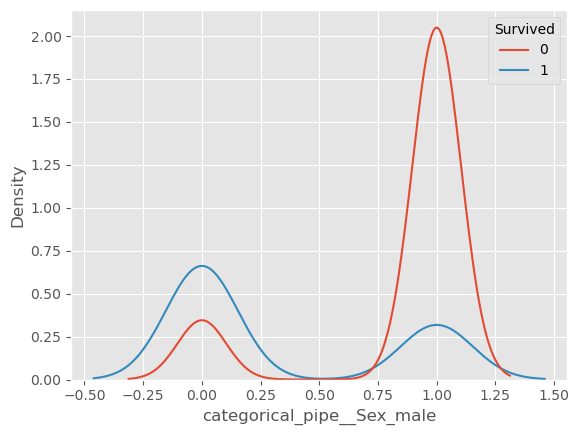

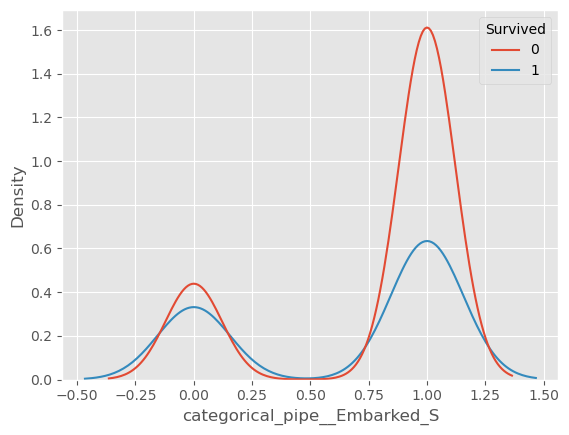

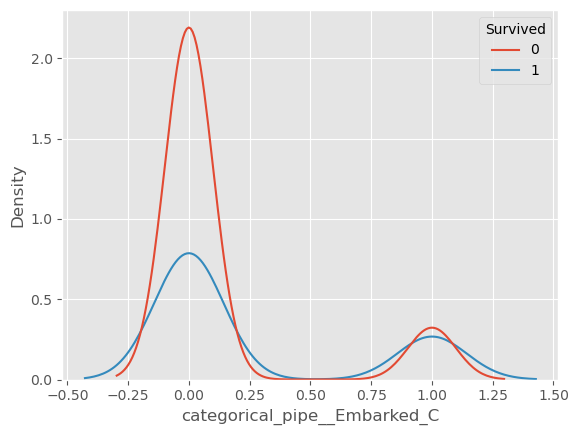

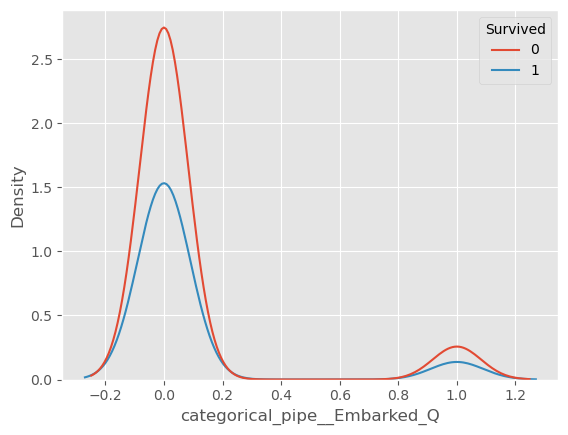

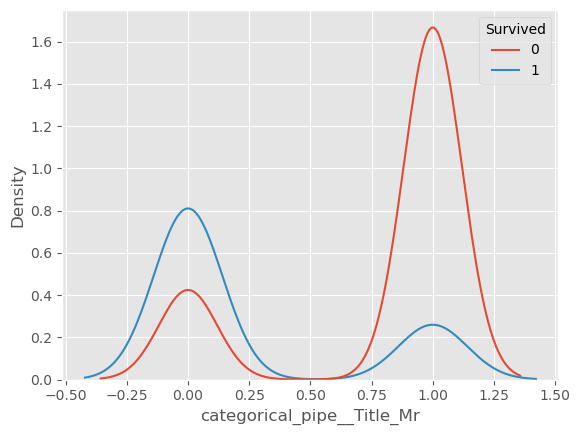

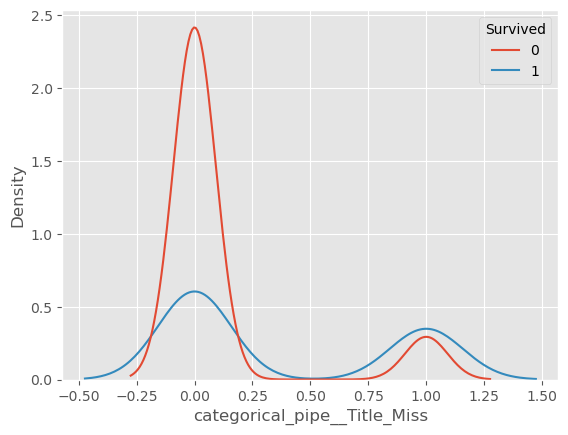

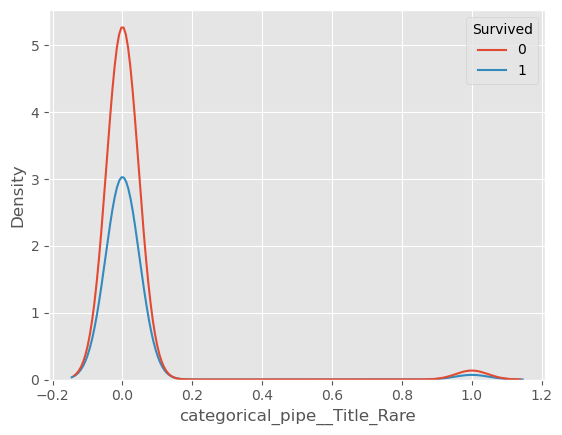

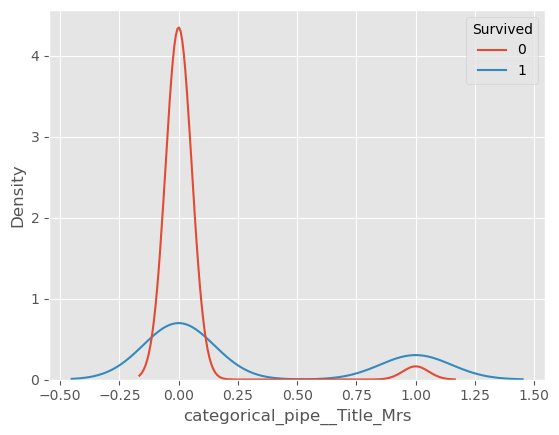

c:\Users\gustavo\Documents\Data Science\08-GitHub\kaggles\Classification\Titanic\src\utils\plots.py:62: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


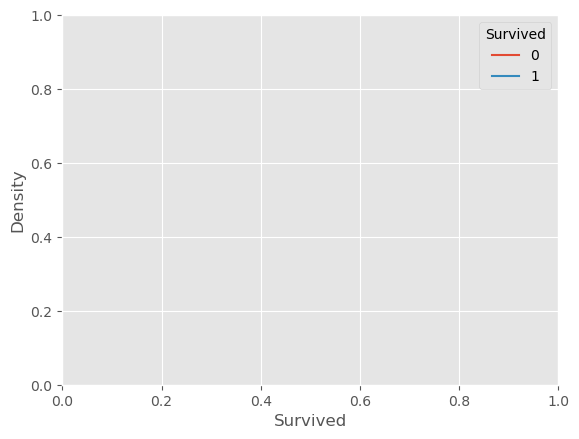

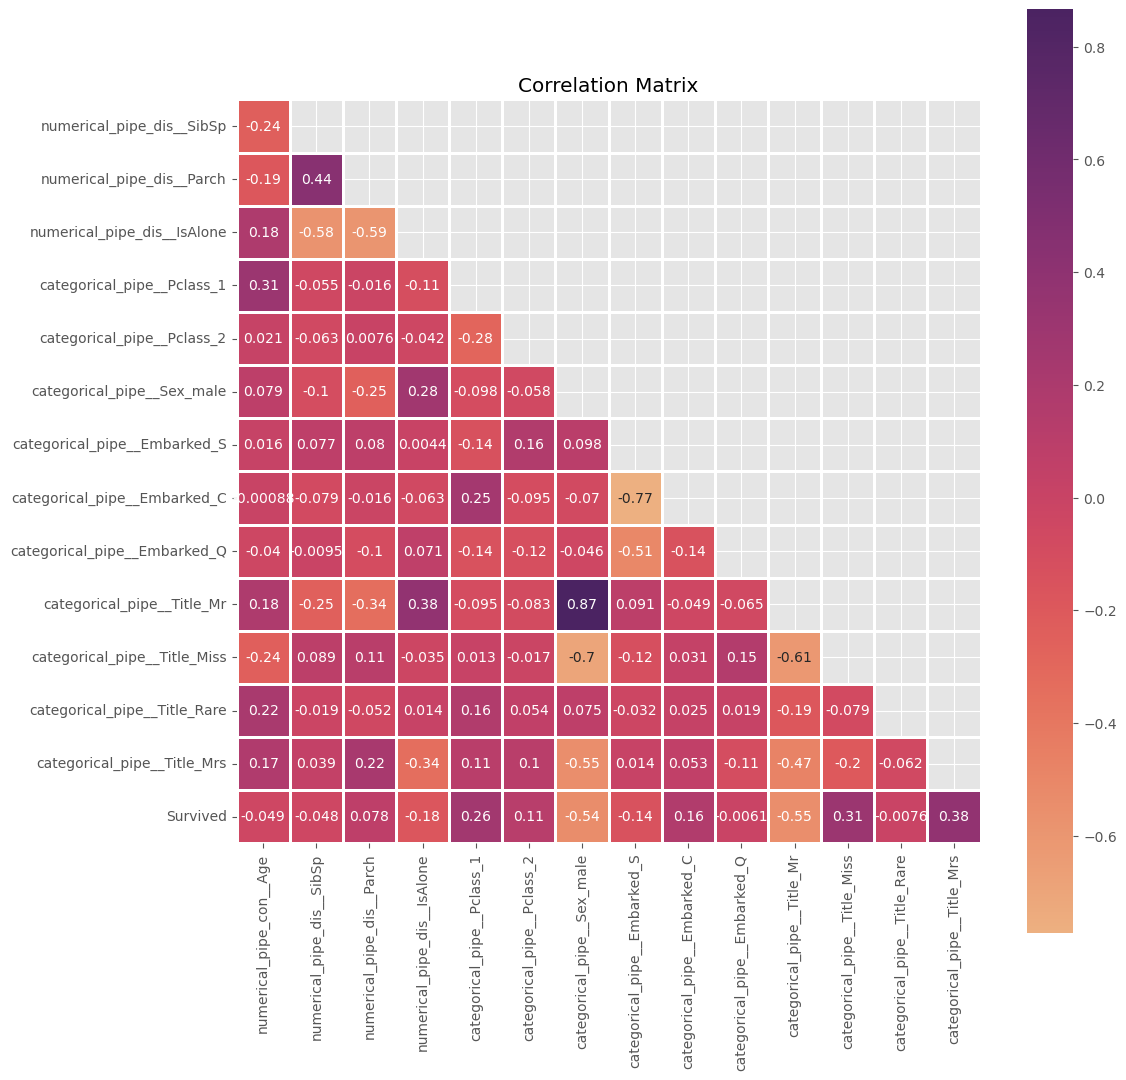

In [13]:
plot_numerical_data(df, target='Survived', classification=True)

# Correlation Analysis

In [14]:
from feature_engine.selection import DropCorrelatedFeatures, SmartCorrelatedSelection

In [15]:
sel = DropCorrelatedFeatures(
    threshold=0.8,
    method='pearson',
    missing_values='ignore'
)


# find correlated features

sel.fit(df)

,variables,None
,method,'pearson'
,threshold,0.8
,missing_values,'ignore'
,confirm_variables,False


In [16]:
sel.correlated_feature_sets_

[{'categorical_pipe__Sex_male', 'categorical_pipe__Title_Mr'}]

## SmartCorrelationSelection

### Model Performance

We will keep a feature from each correlation group based on the performance of a random forest.

In [17]:
# random forest
rf = RandomForestClassifier(
    n_estimators=10,
    random_state=20,
)

# correlation selector
sel = SmartCorrelatedSelection(
    variables=None, # if none, selector examines all numerical variables
    method="pearson",
    threshold=0.8,
    missing_values="raise",
    selection_method="model_performance",
    estimator=rf,
    scoring="roc_auc",
    cv=3,
)

sel.fit(X_train, y_train.values.ravel())

,variables,None
,method,'pearson'
,threshold,0.8
,missing_values,'raise'
,selection_method,'model_performance'
,estimator,RandomForestC...ndom_state=20)
,scoring,'roc_auc'
,cv,3
,groups,None
,confirm_variables,False
,n_estimators,10


In [18]:
sel.correlated_feature_sets_

[{'categorical_pipe__Sex_male', 'categorical_pipe__Title_Mr'}]

In [19]:
sel.features_to_drop_

['categorical_pipe__Sex_male']